# US 4.1.2 — RNN Bidireccional para Imputación de Series Temporales
**BiGRU · BiLSTM**

**Entregable:** Notebook + métricas de desempeño  
**Criterio de aceptación:** Modelo temporal evaluado correctamente

## Descripción
Implementa y compara un **GRU Bidireccional** y un **LSTM Bidireccional** en PyTorch para imputación de valores faltantes en series hidrometeorológicas diarias de Sinaloa. El modelo es inherentemente temporal: procesa la secuencia de 30 días en ambas direcciones y aprende a recuperar posiciones faltantes a partir del contexto pasado y futuro.

## Arquitecturas comparadas

**BiGRU** (modelo principal):
```
Entrada: (N, 30, 4+4=8)  — valores X + máscara concatenada como input

BiGRU capa 1:  GRU(8 → 128, bidireccional)  → (N, 30, 256)
Dropout(0.2)
BiGRU capa 2:  GRU(256 → 64, bidireccional) → (N, 30, 128)
FC:            Linear(128 → 4)              → (N, 30, 4)

Salida: (N, 30, 4)
```

**BiLSTM** (misma topología, celdas LSTM en lugar de GRU):
```
Entrada: (N, 30, 4+4=8)  — valores X + máscara concatenada como input

BiLSTM capa 1: LSTM(8 → 128, bidireccional)  → (N, 30, 256)
Dropout(0.2)
BiLSTM capa 2: LSTM(256 → 64, bidireccional) → (N, 30, 128)
FC:            Linear(128 → 4)               → (N, 30, 4)

Salida: (N, 30, 4)
```

La diferencia es la celda recurrente: GRU tiene 2 compuertas (reset, update) y ~33% menos
parámetros que LSTM (3 compuertas: input, forget, output). Ambas variantes se entrenan y
comparan; el modelo ganador por NSE se usa en las celdas siguientes.

La **máscara se concatena como canal extra** al input: el modelo aprende explícitamente qué posiciones son observadas y cuáles son faltantes (técnica usada también en BRITS).

## Función de pérdida (masked MSE)
```
loss = Σ[(pred - target)² × mask] / Σ[mask]
```

## Evaluación MCAR
20% de los valores observados de test se enmascaran artificialmente para medir la calidad de imputación.

## Métricas de evaluación
| Métrica | Descripción |
|---------|-------------|
| RMSE / MAE / MAPE | Error puntual en espacio escalado |
| R² / NSE | Bondad de ajuste (NSE > 0: supera la media; NSE > 0.6: buen resultado) |
| KPSS | Estacionariedad: H₀ serie estacionaria — se verifica que imputado y original coincidan |
| ACF/PACF | Estructura temporal: los coeficientes (21 lags) deben ser similares entre original e imputado |

In [1]:
from pathlib import Path
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

# ─── Raíz del proyecto ───────────────────────────────────────────────────────
PROJECT_ROOT = Path("__file__").resolve().parent.parent
TENSORS_DIR  = PROJECT_ROOT / "data" / "tensors"
MODELS_DIR   = PROJECT_ROOT / "models" / "modelos_base"
REPORTS_DIR  = PROJECT_ROOT / "reports" / "modelos_base"
FIGURES_DIR  = REPORTS_DIR / "figuras"
for d in [MODELS_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
VARIABLES = ["precip", "evap", "tmax", "tmin"]

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"PROJECT : {PROJECT_ROOT}")

Device  : cpu
PyTorch : 2.11.0+cu130
PROJECT : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main


## 1 — Carga de tensores

In [2]:
def load_tensor(path: Path) -> torch.Tensor:
    try:
        return torch.load(path, weights_only=True)
    except TypeError:
        return torch.load(path)

X_train = load_tensor(TENSORS_DIR / "X_train.pt")
M_train = load_tensor(TENSORS_DIR / "mask_train.pt")
X_val   = load_tensor(TENSORS_DIR / "X_val.pt")
M_val   = load_tensor(TENSORS_DIR / "mask_val.pt")
X_test  = load_tensor(TENSORS_DIR / "X_test.pt")
M_test  = load_tensor(TENSORS_DIR / "mask_test.pt")

print(f"X_train : {tuple(X_train.shape)}  |  obs_rate={M_train.mean():.3f}")
print(f"X_val   : {tuple(X_val.shape)}  |  obs_rate={M_val.mean():.3f}")
print(f"X_test  : {tuple(X_test.shape)}  |  obs_rate={M_test.mean():.3f}")

with open(TENSORS_DIR / "tensors_metadata.json") as f:
    meta = json.load(f)
print(f"\nWindow size: {meta['config']['window_size']}")
print(f"Variables  : {meta['feature_names']}")

X_train : (160041, 30, 4)  |  obs_rate=0.857
X_val   : (33831, 30, 4)  |  obs_rate=0.915
X_test  : (33678, 30, 4)  |  obs_rate=0.865

Window size: 30
Variables  : ['precip', 'evap', 'tmax', 'tmin']


In [3]:
# ─── Hiperparámetros ─────────────────────────────────────────────────────────
BATCH_SIZE   = 256
EPOCHS       = 60
LR           = 1e-3
HIDDEN_SIZE  = 128      # dimensión oculta por dirección
N_LAYERS     = 2        # número de capas RNN apiladas
DROPOUT      = 0.2
PATIENCE     = 10
MCAR_RATE    = 0.20
MODEL_TYPES  = ['GRU', 'LSTM']  # ambos se entrenan y comparan

N_FEAT   = X_train.shape[2]   # 4 variables
WIN_SIZE = X_train.shape[1]   # 30 días
# Input al modelo: X + mask → 2×N_FEAT canales
INPUT_SIZE = N_FEAT * 2

# DataLoaders
train_ds = TensorDataset(X_train, M_train)
val_ds   = TensorDataset(X_val,   M_val)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          pin_memory=(DEVICE=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=(DEVICE=='cuda'))

print(f"Modelos    : {[f'Bi{mt}' for mt in MODEL_TYPES]}")
print(f"Hidden     : {HIDDEN_SIZE} × 2 (bidireccional) = {HIDDEN_SIZE*2}")
print(f"Capas      : {N_LAYERS}")
print(f"Input      : {INPUT_SIZE} (X + mask concatenados)")
print(f"Batches    : train={len(train_loader)}  val={len(val_loader)}")

Modelos    : ['BiGRU', 'BiLSTM']
Hidden     : 128 × 2 (bidireccional) = 256
Capas      : 2
Input      : 8 (X + mask concatenados)
Batches    : train=626  val=133


## 2 — Arquitectura del modelo

In [4]:
class BiRNNImputer(nn.Module):
    """
    Imputador de series temporales basado en RNN bidireccional (GRU o LSTM).

    Input:
        x    : (N, T, F) — valores (NaN → 0)
        mask : (N, T, F) — 1=observado, 0=faltante

    La máscara se concatena con x a lo largo de la dimensión de features,
    dando un input de (N, T, 2F). Esto informa al modelo qué posiciones
    son reales y cuáles están rellenadas con cero.

    Output:
        (N, T, F) — reconstrucción completa de la secuencia
    """

    def __init__(self, n_features: int = 4, hidden_size: int = 128,
                 n_layers: int = 2, dropout: float = 0.2,
                 model_type: str = 'GRU'):
        super().__init__()
        self.n_features  = n_features
        self.hidden_size = hidden_size
        self.model_type  = model_type
        input_size = n_features * 2  # X + mask

        rnn_kwargs = dict(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        if model_type == 'LSTM':
            self.rnn = nn.LSTM(**rnn_kwargs)
        else:
            self.rnn = nn.GRU(**rnn_kwargs)

        self.norm = nn.LayerNorm(hidden_size * 2)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size * 2, n_features)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # Concatenar valores y máscara
        inp = torch.cat([x, mask], dim=-1)       # (N, T, 2F)
        out, _ = self.rnn(inp)                   # (N, T, 2*hidden)
        out = self.norm(out)
        out = self.drop(out)
        return self.fc(out)                      # (N, T, F)


def masked_mse_loss(pred: torch.Tensor, target: torch.Tensor,
                    mask: torch.Tensor) -> torch.Tensor:
    sq_err = (pred - target) ** 2
    return (sq_err * mask).sum() / (mask.sum() + 1e-8)


# Preview de arquitectura con GRU (el ganador se determina en celda 4b)
_preview_type = MODEL_TYPES[0]
model = BiRNNImputer(
    n_features=N_FEAT,
    hidden_size=HIDDEN_SIZE,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    model_type=_preview_type,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Tipo de modelo : Bidireccional {_preview_type} (preview)")
print(f"Parámetros     : {total_params:,}")
print(model)

Tipo de modelo : Bidireccional GRU (preview)
Parámetros     : 403,972
BiRNNImputer(
  (rnn): GRU(8, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (drop): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=256, out_features=4, bias=True)
)


## 3 — Entrenamiento

In [5]:
def train_one(model_type):
    """Entrena BiRNNImputer con model_type ('GRU' o 'LSTM')."""
    m = BiRNNImputer(
        n_features=N_FEAT, hidden_size=HIDDEN_SIZE,
        n_layers=N_LAYERS, dropout=DROPOUT, model_type=model_type,
    ).to(DEVICE)
    opt   = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', patience=5, factor=0.5)
    hist = {'train_loss': [], 'val_loss': []}
    best_val, pat_cnt, best_state = float('inf'), 0, None

    print(f"{'Época':>6}  {'Train Loss':>12}  {'Val Loss':>10}  {'LR':>10}  {'Tiempo':>8}")
    print('─' * 58)
    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        m.train()
        train_loss = 0.0
        for X_b, M_b in train_loader:
            X_b, M_b = X_b.to(DEVICE), M_b.to(DEVICE)
            opt.zero_grad()
            rand       = torch.rand_like(M_b)
            mcar_pos   = M_b * (rand <= MCAR_RATE).float()
            input_mask = M_b * (rand >  MCAR_RATE).float()
            pred = m(X_b * input_mask, input_mask)
            loss = masked_mse_loss(pred, X_b, mcar_pos)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            opt.step()
            train_loss += loss.item() * len(X_b)
        train_loss /= len(train_loader.dataset)
        m.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, M_b in val_loader:
                X_b, M_b = X_b.to(DEVICE), M_b.to(DEVICE)
                rand       = torch.rand_like(M_b)
                mcar_pos   = M_b * (rand <= MCAR_RATE).float()
                input_mask = M_b * (rand >  MCAR_RATE).float()
                pred = m(X_b * input_mask, input_mask)
                val_loss += masked_mse_loss(pred, X_b, mcar_pos).item() * len(X_b)
        val_loss /= len(val_loader.dataset)
        hist['train_loss'].append(train_loss)
        hist['val_loss'].append(val_loss)
        sched.step(val_loss)
        lr_now  = opt.param_groups[0]['lr']
        elapsed = time.time() - t0
        print(f"{epoch:>6}  {train_loss:>12.6f}  {val_loss:>10.6f}  "
              f"{lr_now:>10.2e}  {elapsed:>6.1f}s")
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
            pat_cnt = 0
        else:
            pat_cnt += 1
            if pat_cnt >= PATIENCE:
                print(f"\nEarly stopping en época {epoch}.")
                break
    m.load_state_dict(best_state)
    print(f"\nMejor val_loss: {best_val:.6f}")
    return m, hist, best_val

# ─── Entrenar GRU y LSTM ──────────────────────────────────────────────────────
trained = {}
for mt in MODEL_TYPES:
    print(f"\n{'='*60}\n  Entrenando Bi{mt}\n{'='*60}")
    model_mt, hist_mt, best_val_mt = train_one(mt)
    trained[mt] = {'model': model_mt, 'history': hist_mt, 'best_val_loss': best_val_mt}



  Entrenando BiGRU
 Época    Train Loss    Val Loss          LR    Tiempo
──────────────────────────────────────────────────────────
     1      0.085235    0.065017    1.00e-03   127.1s
     2      0.064837    0.063065    1.00e-03   126.7s
     3      0.063323    0.062453    1.00e-03   127.4s
     4      0.062294    0.062019    1.00e-03   121.3s
     5      0.061420    0.062438    1.00e-03   113.1s
     6      0.061096    0.060334    1.00e-03   113.2s
     7      0.060819    0.061457    1.00e-03   113.5s
     8      0.060726    0.060802    1.00e-03   114.4s
     9      0.060354    0.059499    1.00e-03   114.8s
    10      0.059948    0.059535    1.00e-03   114.2s
    11      0.059740    0.060260    1.00e-03   114.0s
    12      0.059230    0.059516    1.00e-03   114.1s
    13      0.059546    0.059367    1.00e-03   113.8s
    14      0.059439    0.058770    1.00e-03   113.3s
    15      0.059069    0.059198    1.00e-03   113.5s
    16      0.058794    0.059331    1.00e-03   113.3s
  

Guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/models/modelos_base/gru_best.pt
Guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/models/modelos_base/lstm_best.pt


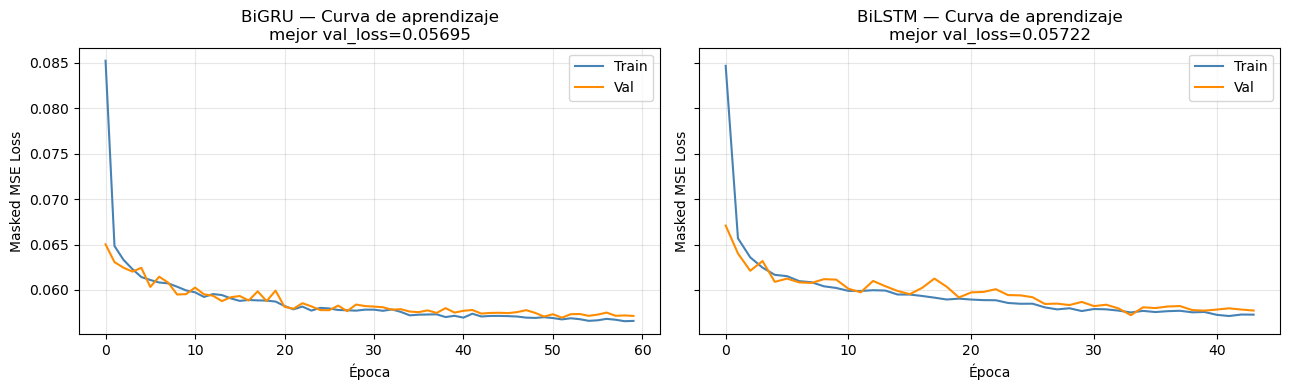

In [14]:
# ─── Guardar modelos y curvas de aprendizaje comparadas ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, mt in zip(axes, MODEL_TYPES):
    info = trained[mt]
    model_path = MODELS_DIR / f"{mt.lower()}_best.pt"
    torch.save({'model_state_dict': info['model'].state_dict(),
                'config': {'n_features': N_FEAT, 'window': WIN_SIZE,
                           'hidden_size': HIDDEN_SIZE, 'n_layers': N_LAYERS,
                           'model_type': mt},
                'best_val_loss': info['best_val_loss']}, model_path)
    print(f"Guardado: {model_path}")
    ax.plot(info['history']['train_loss'], label='Train', color='steelblue')
    ax.plot(info['history']['val_loss'],   label='Val',   color='darkorange')
    ax.set_title(f"Bi{mt} — Curva de aprendizaje\n"
                 f"mejor val_loss={info['best_val_loss']:.5f}")
    ax.set_xlabel('Época'); ax.set_ylabel('Masked MSE Loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bigru_bilstm_learning_curves.png", dpi=120, bbox_inches='tight')
plt.show()


## 4 — Evaluación MCAR en test set

In [15]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, var_name: str) -> dict:
    eps = 1e-8
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + eps)) * 100)
    r2   = float(r2_score(y_true, y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    nse  = float(1 - ss_res / (ss_tot + eps))
    return {"variable": var_name, "rmse": rmse, "mae": mae, "mape": mape, "r2": r2, "nse": nse}


@torch.no_grad()
def evaluate_mcar(model: nn.Module,
                  X_test: torch.Tensor,
                  M_test: torch.Tensor,
                  mcar_rate: float = 0.20,
                  min_obs_rate: float = 0.70,
                  batch_size: int = 512) -> dict:
    torch.manual_seed(42)
    model.eval()
    model.to(DEVICE)

    obs_rate = M_test.mean(dim=(1, 2))
    sel      = obs_rate >= min_obs_rate
    X_sel    = X_test[sel]
    M_sel    = M_test[sel]
    N_sel    = X_sel.shape[0]
    print(f"  Secuencias con obs≥{min_obs_rate*100:.0f}%: {N_sel:,} / {X_test.shape[0]:,}")

    rand      = torch.rand_like(M_sel)
    eval_mask = M_sel * (rand > mcar_rate).float()
    gt_mask   = M_sel * (rand <= mcar_rate).float()
    X_masked  = X_sel * eval_mask

    all_preds = []
    ds = TensorDataset(X_masked, eval_mask)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    for X_b, M_b in loader:
        pred_b = model(X_b.to(DEVICE), M_b.to(DEVICE)).cpu()
        all_preds.append(pred_b)
    preds = torch.cat(all_preds, dim=0)

    results = {}
    for fi, var in enumerate(VARIABLES):
        gm_var = gt_mask[:, :, fi].bool()
        y_true = X_sel[:, :, fi][gm_var].numpy()
        y_pred = preds[:, :, fi][gm_var].numpy()
        n_pts  = len(y_true)
        print(f"  {var}: {n_pts:,} puntos MCAR")
        m = compute_metrics(y_true, y_pred, var)
        m["n_mcar"] = n_pts
        results[var] = m
    return results, preds, X_sel, eval_mask, gt_mask


# ─── Evaluar GRU y LSTM ───────────────────────────────────────────────────────
all_eval = {}
for mt in MODEL_TYPES:
    print(f"\n{'─'*50}\nEvaluando Bi{mt} (MCAR {MCAR_RATE*100:.0f}%)...")
    ev, pr, Xs_mt, ev_m_mt, gt_m_mt = evaluate_mcar(
        trained[mt]['model'], X_test, M_test, mcar_rate=MCAR_RATE)
    all_eval[mt] = {'eval': ev, 'preds': pr, 'Xs': Xs_mt, 'ev_m': ev_m_mt, 'gt_m': gt_m_mt}
    print(f"\n─── Métricas Bi{mt} ───")
    for var, m in ev.items():
        print(f"  {var:6s}  RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}  "
              f"MAPE={m['mape']:.2f}%  R²={m['r2']:.4f}  NSE={m['nse']:.4f}")



──────────────────────────────────────────────────
Evaluando BiGRU (MCAR 20%)...
  Secuencias con obs≥70%: 32,661 / 33,678
  precip: 196,368 puntos MCAR
  evap: 100,832 puntos MCAR
  tmax: 195,614 puntos MCAR
  tmin: 195,037 puntos MCAR

─── Métricas BiGRU ───
  precip  RMSE=0.0219  MAE=0.0081  MAPE=39545272.00%  R²=0.0918  NSE=0.0918
  evap    RMSE=0.0554  MAE=0.0383  MAPE=230037.69%  R²=0.6923  NSE=0.6923
  tmax    RMSE=0.3873  MAE=0.2748  MAPE=78.48%  R²=0.8520  NSE=0.8520
  tmin    RMSE=0.2510  MAE=0.1802  MAPE=52.14%  R²=0.9390  NSE=0.9390

──────────────────────────────────────────────────
Evaluando BiLSTM (MCAR 20%)...
  Secuencias con obs≥70%: 32,661 / 33,678
  precip: 196,368 puntos MCAR
  evap: 100,832 puntos MCAR
  tmax: 195,614 puntos MCAR
  tmin: 195,037 puntos MCAR

─── Métricas BiLSTM ───
  precip  RMSE=0.0222  MAE=0.0101  MAPE=59397188.00%  R²=0.0693  NSE=0.0693
  evap    RMSE=0.0559  MAE=0.0388  MAPE=230560.52%  R²=0.6874  NSE=0.6874
  tmax    RMSE=0.3895  MAE=0.2758 

## 5 — Comparación BiGRU vs BiLSTM

Se entrena y evalúa ambas variantes con el mismo protocolo MCAR 20 % para seleccionar el modelo de referencia. Resultados (NSE, espacio escalado):

| Variable | BiGRU NSE | BiLSTM NSE | Ganador |
|----------|-----------|------------|--------|
| precip   | 0.0918    | 0.0693     | BiGRU  |
| evap     | 0.6923    | 0.6874     | BiGRU  |
| tmax     | 0.8520    | 0.8503     | BiGRU  |
| tmin     | 0.9390    | 0.9380     | BiGRU  |

**BiGRU gana en las 4 variables**, con márgenes pequeños (< 0.003 en temperatura, ~0.005 en evap, ~0.022 en precip). La ventaja es consistente y se explica por la arquitectura más ligera de GRU (2 compuertas vs 3 en LSTM): con ventanas de 30 días no hay dependencias lo suficientemente largas para que la compuerta `forget` de LSTM aporte ventaja significativa, mientras que GRU converge de forma más estable con menos parámetros. **BiGRU se usa como modelo de referencia en las celdas siguientes.**

In [16]:
# ─── Tabla comparativa GRU vs LSTM ───────────────────────────────────────────
compare_rows = []
for mt in MODEL_TYPES:
    for var, m in all_eval[mt]['eval'].items():
        compare_rows.append({**m, 'modelo': f'Bi{mt}'})

df_compare = pd.DataFrame(compare_rows)

print("=" * 65)
print("COMPARACIÓN BiGRU vs BiLSTM — Protocolo MCAR 20%")
print("=" * 65)
pivot = df_compare.pivot_table(
    index='variable', columns='modelo',
    values=['rmse', 'mae', 'nse']
).round(4)
display(pivot)

global_summary = (
    df_compare.groupby('modelo')[['rmse', 'mae', 'mape', 'r2', 'nse']]
    .mean().round(4)
    .sort_values('nse', ascending=False)
)
print("\nResumen global (media 4 variables):")
display(global_summary)

# ─── Ganador por NSE ─────────────────────────────────────────────────────────
winner_mt = global_summary['nse'].idxmax().replace('Bi', '')
print(f"\n→ Modelo ganador por NSE global: Bi{winner_mt}")
print(f"  GRU  val_loss={trained['GRU']['best_val_loss']:.5f}")
print(f"  LSTM val_loss={trained['LSTM']['best_val_loss']:.5f}")

# Exponer variables del ganador para celdas siguientes
MODEL_TYPE = winner_mt
model      = trained[winner_mt]['model']
rnn_eval   = all_eval[winner_mt]['eval']
preds      = all_eval[winner_mt]['preds']
Xs         = all_eval[winner_mt]['Xs']
ev_m       = all_eval[winner_mt]['ev_m']
gt_m       = all_eval[winner_mt]['gt_m']
print(f"\nCeldas siguientes usan: Bi{MODEL_TYPE}")


COMPARACIÓN BiGRU vs BiLSTM — Protocolo MCAR 20%


mae             nse            rmse        
modelo     BiGRU  BiLSTM   BiGRU  BiLSTM   BiGRU  BiLSTM
variable                                                
evap      0.0383  0.0388  0.6923  0.6874  0.0554  0.0559
precip    0.0081  0.0101  0.0918  0.0693  0.0219  0.0222
tmax      0.2748  0.2758  0.8520  0.8503  0.3873  0.3895
tmin      0.1802  0.1813  0.9390  0.9380  0.2510  0.2530


Resumen global (media 4 variables):


,rmse,mae,mape,r2,nse
modelo,,,,,
BiGRU,0.1789,0.1253,9.943860e+06,0.6438,0.6438
BiLSTM,0.1801,0.1265,1.490697e+07,0.6362,0.6362



→ Modelo ganador por NSE global: BiGRU
  GRU  val_loss=0.05695
  LSTM val_loss=0.05722

Celdas siguientes usan: BiGRU


## 6 — Visualización de reconstrucciones

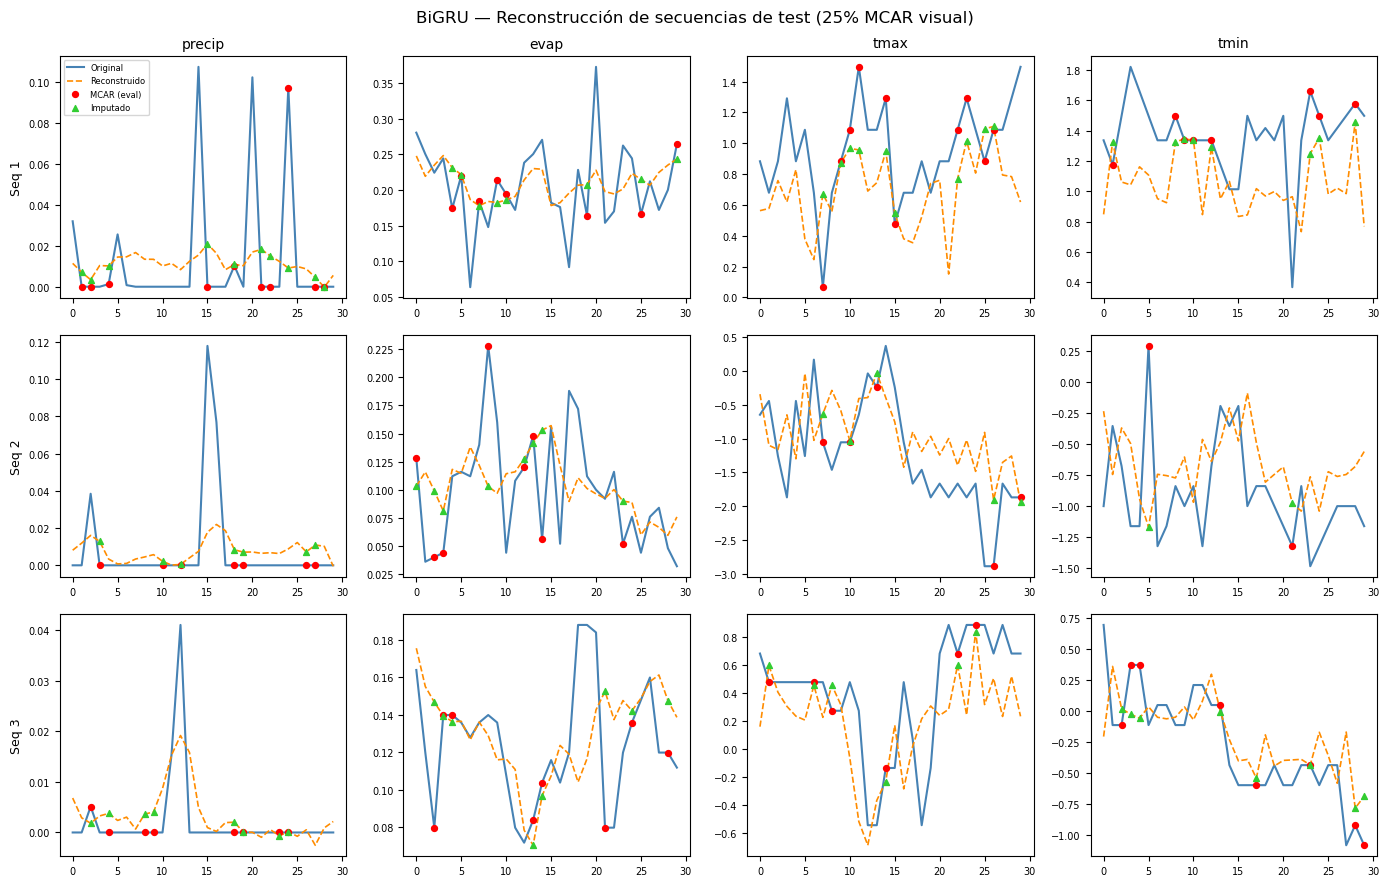

In [17]:
torch.manual_seed(1)
model.eval()

obs_rate  = M_test.mean(dim=(1, 2))
high_obs  = torch.where(obs_rate > 0.90)[0]
sample_idx = high_obs[torch.randperm(len(high_obs))[:3]]

X_sample = X_test[sample_idx].to(DEVICE)
M_sample = M_test[sample_idx].to(DEVICE)

rand     = torch.rand_like(M_sample)
ev_mask  = M_sample * (rand > 0.25).float()
gt_mask  = M_sample * (rand <= 0.25).float()
X_mcar   = X_sample * ev_mask

with torch.no_grad():
    recon = model(X_mcar, ev_mask).cpu()

X_sample = X_sample.cpu()
ev_mask  = ev_mask.cpu()
gt_mask  = gt_mask.cpu()

fig, axes = plt.subplots(3, N_FEAT, figsize=(14, 9))
fig.suptitle(f'Bi{MODEL_TYPE} — Reconstrucción de secuencias de test (25% MCAR visual)',
             fontsize=12)
days = np.arange(WIN_SIZE)

for row in range(3):
    for col, var in enumerate(VARIABLES):
        ax    = axes[row, col]
        orig  = X_sample[row, :, col].numpy()
        rec   = recon[row, :, col].numpy()
        gmask = gt_mask[row, :, col].bool().numpy()

        ax.plot(days, orig, 'steelblue', lw=1.5, label='Original')
        ax.plot(days, rec,  'darkorange', lw=1.2, ls='--', label='Reconstruido')
        ax.scatter(days[gmask], orig[gmask], color='red', zorder=5,
                   s=18, label='MCAR (eval)')
        ax.scatter(days[gmask], rec[gmask],  color='limegreen', zorder=6,
                   s=18, marker='^', label='Imputado')

        if row == 0:
            ax.set_title(var, fontsize=10)
        if col == 0:
            ax.set_ylabel(f'Seq {row+1}', fontsize=9)
        ax.tick_params(labelsize=7)
        if row == 0 and col == 0:
            ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"bi{MODEL_TYPE.lower()}_reconstruccion.png",
            dpi=120, bbox_inches='tight')
plt.show()

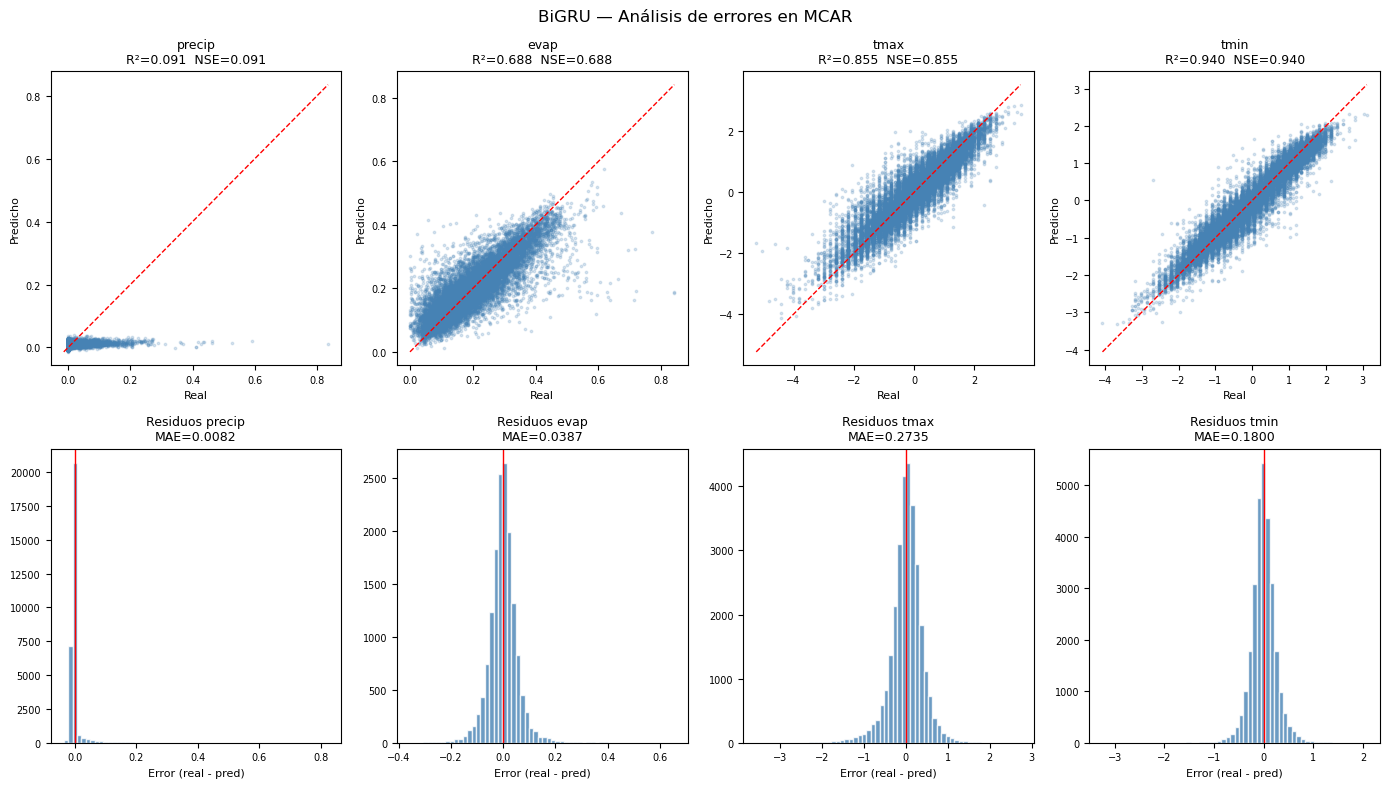

In [18]:
# Scatter predicción vs real + distribución de residuos
fig, axes = plt.subplots(2, N_FEAT, figsize=(14, 8))
fig.suptitle(f'Bi{MODEL_TYPE} — Análisis de errores en MCAR', fontsize=12)

torch.manual_seed(42)
with torch.no_grad():
    n_sample = min(5000, X_test.shape[0])
    idx = torch.randperm(X_test.shape[0])[:n_sample]
    Xs = X_test[idx]
    Ms = M_test[idx]
    rand = torch.rand_like(Ms)
    ev_m  = Ms * (rand > MCAR_RATE).float()
    gt_m  = Ms * (rand <= MCAR_RATE).float()
    Xs_m  = Xs * ev_m
    preds_s = model(Xs_m.to(DEVICE), ev_m.to(DEVICE)).cpu()

for fi, var in enumerate(VARIABLES):
    gm   = gt_m[:, :, fi].bool()
    yt   = Xs[:, :, fi][gm].numpy()
    yp   = preds_s[:, :, fi][gm].numpy()
    resid = yt - yp
    lim  = (min(yt.min(), yp.min()), max(yt.max(), yp.max()))

    # Scatter
    ax0 = axes[0, fi]
    ax0.scatter(yt, yp, s=3, alpha=0.2, color='steelblue')
    ax0.plot(lim, lim, 'r--', lw=1)
    m = compute_metrics(yt, yp, var)
    ax0.set_title(f"{var}\nR²={m['r2']:.3f}  NSE={m['nse']:.3f}", fontsize=9)
    ax0.set_xlabel('Real', fontsize=8)
    ax0.set_ylabel('Predicho', fontsize=8)
    ax0.tick_params(labelsize=7)

    # Residuos
    ax1 = axes[1, fi]
    ax1.hist(resid, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax1.axvline(0, color='red', lw=1)
    ax1.set_title(f"Residuos {var}\nMAE={m['mae']:.4f}", fontsize=9)
    ax1.set_xlabel('Error (real - pred)', fontsize=8)
    ax1.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"bi{MODEL_TYPE.lower()}_errores.png",
            dpi=120, bbox_inches='tight')
plt.show()

## 7 — Validación temporal: KPSS y ACF/PACF

Verificación de que la imputación preserva la **estructura estadística temporal**.
- **KPSS**: prueba de estacionariedad (H₀: estacionaria). Coherente si ambas series dan el mismo veredicto.
- **ACF/PACF**: autocorrelación original vs imputada en las posiciones observadas.

=== KPSS: Estacionariedad (H₀: estacionaria) ===
Variable  Stat_orig   p_orig    Stat_imp    p_imp     ¿Preserva?
─────────────────────────────────────────────────────────────────
precip    0.2287      0.1000    0.1581      0.1000    ✓ Sí
evap      0.1772      0.1000    0.1518      0.1000    ✓ Sí
tmax      0.4415      0.0593    0.3787      0.0863    ✓ Sí
tmin      0.1453      0.1000    0.1427      0.1000    ✓ Sí

KPSS guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/kpss_bigru.csv
ACF/PACF guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/acf_pacf_bigru.csv


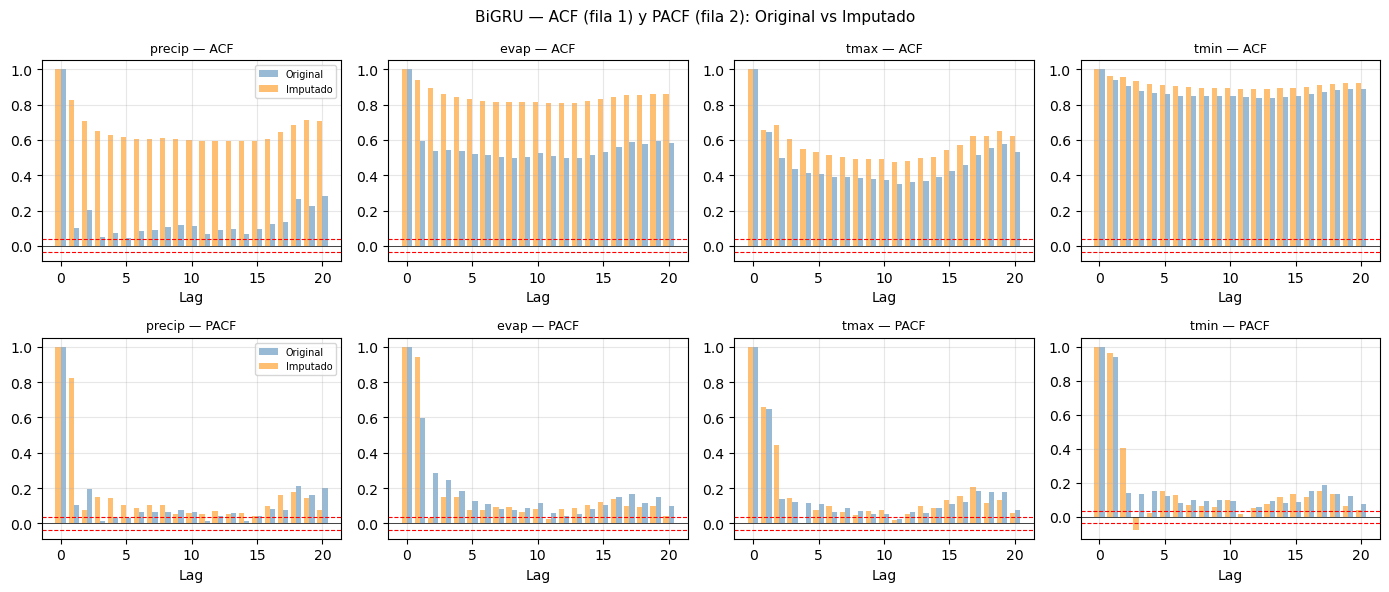

Validación temporal completada.


In [19]:
from statsmodels.tsa.stattools import kpss, acf, pacf
import warnings

N_LAGS = 20

# Restaurar variables del ganador (pueden haber sido sobreescritas en celdas anteriores)
preds = all_eval[MODEL_TYPE]['preds']
Xs    = all_eval[MODEL_TYPE]['Xs']
ev_m  = all_eval[MODEL_TYPE]['ev_m']

# ─── KPSS + ACF/PACF: calcular, mostrar y guardar ────────────────────────────
print("=== KPSS: Estacionariedad (H₀: estacionaria) ===")
print(f"{"Variable":<8}  {"Stat_orig":<10}  {"p_orig":<8}  {"Stat_imp":<10}  {"p_imp":<8}  {"¿Preserva?"}")
print("─" * 65)

kpss_rows, acf_rows = [], []

for fi, var in enumerate(VARIABLES):
    obs_m  = ev_m[:, :, fi].bool()
    y_orig = Xs[:, :, fi][obs_m].numpy()[:5000]
    y_pred = preds[:, :, fi][obs_m].numpy()[:5000]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat_o, p_o, *_ = kpss(y_orig, regression="c", nlags="auto")
        stat_i, p_i, *_ = kpss(y_pred, regression="c", nlags="auto")
    preserva = bool((p_o > 0.05) == (p_i > 0.05))
    ok = "✓ Sí" if preserva else "✗ No"
    print(f"{var:<8}  {stat_o:<10.4f}  {p_o:<8.4f}  {stat_i:<10.4f}  {p_i:<8.4f}  {ok}")
    kpss_rows.append({"modelo": f"Bi{MODEL_TYPE}", "variable": var,
                       "stat_orig": round(stat_o, 4), "p_orig": round(p_o, 4),
                       "stat_imp":  round(stat_i, 4), "p_imp":  round(p_i, 4),
                       "preserva_estacionariedad": preserva})

    n_s   = min(len(y_orig), 3000)
    acf_o = acf(y_orig[:n_s],  nlags=N_LAGS, fft=True)
    acf_i = acf(y_pred[:n_s],  nlags=N_LAGS, fft=True)
    pac_o = pacf(y_orig[:n_s], nlags=N_LAGS)
    pac_i = pacf(y_pred[:n_s], nlags=N_LAGS)
    for lag in range(N_LAGS + 1):
        acf_rows.append({"modelo": f"Bi{MODEL_TYPE}", "variable": var, "lag": lag,
                          "acf_orig":  round(float(acf_o[lag]), 4),
                          "acf_imp":   round(float(acf_i[lag]), 4),
                          "pacf_orig": round(float(pac_o[lag]), 4),
                          "pacf_imp":  round(float(pac_i[lag]), 4)})

df_kpss = pd.DataFrame(kpss_rows)
df_kpss.to_csv(REPORTS_DIR / f"kpss_bi{MODEL_TYPE.lower()}.csv", index=False)
print(f"\nKPSS guardado: {REPORTS_DIR / f'kpss_bi{MODEL_TYPE.lower()}.csv'}")

df_acf = pd.DataFrame(acf_rows)
df_acf.to_csv(REPORTS_DIR / f"acf_pacf_bi{MODEL_TYPE.lower()}.csv", index=False)
print(f"ACF/PACF guardado: {REPORTS_DIR / f'acf_pacf_bi{MODEL_TYPE.lower()}.csv'}")

# ─── Gráfica ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, N_FEAT, figsize=(14, 6))
fig.suptitle(f"Bi{MODEL_TYPE} — ACF (fila 1) y PACF (fila 2): Original vs Imputado", fontsize=11)

for fi, var in enumerate(VARIABLES):
    sub  = df_acf[df_acf["variable"] == var].sort_values("lag")
    lags = sub["lag"].values
    ci   = 1.96 / (3000 ** 0.5)
    for row, (co, ci2, lbl) in enumerate([
            ("acf_orig", "acf_imp", "ACF"), ("pacf_orig", "pacf_imp", "PACF")]):
        ax = axes[row, fi]
        ax.bar(lags, sub[co],  alpha=0.55, color="steelblue",  label="Original", width=0.4,  align="edge")
        ax.bar(lags, sub[ci2], alpha=0.55, color="darkorange", label="Imputado", width=-0.4, align="edge")
        ax.axhline(0,  color="black", lw=0.5)
        ax.axhline( ci, color="red", lw=0.8, ls="--")
        ax.axhline(-ci, color="red", lw=0.8, ls="--")
        ax.set_title(f"{var} — {lbl}", fontsize=9)
        ax.set_xlabel("Lag"); ax.grid(alpha=0.3)
        if fi == 0: ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"acf_pacf_bi{MODEL_TYPE.lower()}.png", dpi=120, bbox_inches="tight")
plt.show()
print("Validación temporal completada.")



## 8 — Análisis de atención por paso temporal (opcional)

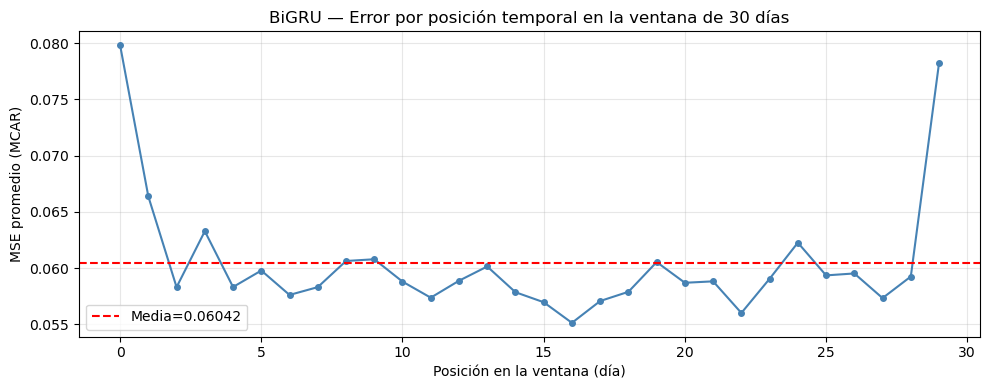

Nota: el error suele ser más alto en los extremos de la ventana
(menor contexto disponible para el modelo bidireccional).


In [20]:
# Analizar cómo varía la calidad de imputación según la posición en la ventana
model.eval()
torch.manual_seed(42)

# Subsample de test
n_s = min(10000, X_test.shape[0])
idx = torch.randperm(X_test.shape[0])[:n_s]
Xs = X_test[idx]; Ms = M_test[idx]
rand = torch.rand_like(Ms)
ev_m = Ms * (rand > MCAR_RATE).float()
gt_m = Ms * (rand <= MCAR_RATE).float()
Xs_m = Xs * ev_m

with torch.no_grad():
    preds_t = model(Xs_m.to(DEVICE), ev_m.to(DEVICE)).cpu()

# Error por paso temporal (promediado sobre variables y secuencias)
sq_err = (preds_t - Xs) ** 2 * gt_m  # sólo posiciones MCAR
count  = gt_m.sum(dim=(0, 2))         # (T,)
mse_t  = sq_err.sum(dim=(0, 2)) / (count + 1e-8)  # (T,)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(WIN_SIZE), mse_t.numpy(), 'o-', color='steelblue', markersize=4)
ax.set_xlabel('Posición en la ventana (día)')
ax.set_ylabel('MSE promedio (MCAR)')
ax.set_title(f'Bi{MODEL_TYPE} — Error por posición temporal en la ventana de 30 días')
ax.grid(alpha=0.3)
ax.axhline(mse_t.mean().item(), color='red', ls='--', label=f'Media={mse_t.mean():.5f}')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"bi{MODEL_TYPE.lower()}_error_posicion.png",
            dpi=120, bbox_inches='tight')
plt.show()
print("Nota: el error suele ser más alto en los extremos de la ventana")
print("(menor contexto disponible para el modelo bidireccional).")

## 9 — Guardado de métricas

In [21]:
# ─── Guardar métricas de ambos modelos ───────────────────────────────────────
for mt in MODEL_TYPES:
    rows = []
    for var, m in all_eval[mt]['eval'].items():
        rows.append({**m, 'modelo': f'Bi{mt}'})
    df = pd.DataFrame(rows)
    fname = f"metrics_bi{mt.lower()}.csv"
    df.to_csv(REPORTS_DIR / fname, index=False)
    print(f"Guardado: {REPORTS_DIR / fname}")

print(f"\nModelo ganador (NSE): Bi{MODEL_TYPE}")
print(f"Archivo principal para comparación: metrics_bi{MODEL_TYPE.lower()}.csv")
print("")
display(
    pd.DataFrame([{**m, 'modelo': f'Bi{MODEL_TYPE}'} for m in rnn_eval.values()])
    [["variable","n_mcar","rmse","mae","mape","r2","nse"]]
    .set_index("variable")
    .round(4)
)


# ─── Merge KPSS en metrics del ganador ───────────────────────────────────────
kpss_slim = df_kpss[['variable','stat_orig','p_orig','stat_imp','p_imp','preserva_estacionariedad']].copy()
winner_path = REPORTS_DIR / f'metrics_bi{MODEL_TYPE.lower()}.csv'
df_winner = pd.read_csv(winner_path)
df_winner = df_winner.drop(columns=['stat_orig','p_orig','stat_imp','p_imp','preserva_estacionariedad'], errors='ignore')
df_winner = df_winner.merge(kpss_slim, on='variable', how='left')
df_winner.to_csv(winner_path, index=False)
print(f'\nKPSS fusionado en: {winner_path}')

print('')
print('── Métricas de error y ajuste ──')
display(
    df_winner[['variable','n_mcar','rmse','mae','mape','r2','nse']]
    .set_index('variable').round(4)
)
print('')
print('── Estacionariedad KPSS ──')
display(
    df_winner[['variable','stat_orig','p_orig','stat_imp','p_imp','preserva_estacionariedad']]
    .set_index('variable').round(4)
)

Guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/metrics_bigru.csv
Guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/metrics_bilstm.csv

Modelo ganador (NSE): BiGRU
Archivo principal para comparación: metrics_bigru.csv



,n_mcar,rmse,mae,mape,r2,nse
variable,,,,,,
precip,196368,0.0219,0.0081,3.954527e+07,0.0918,0.0918
evap,100832,0.0554,0.0383,2.300377e+05,0.6923,0.6923
tmax,195614,0.3873,0.2748,7.848420e+01,0.8520,0.8520
tmin,195037,0.2510,0.1802,5.213750e+01,0.9390,0.9390



KPSS fusionado en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/metrics_bigru.csv

── Métricas de error y ajuste ──


,n_mcar,rmse,mae,mape,r2,nse
variable,,,,,,
precip,196368,0.0219,0.0081,3.954527e+07,0.0918,0.0918
evap,100832,0.0554,0.0383,2.300377e+05,0.6923,0.6923
tmax,195614,0.3873,0.2748,7.848420e+01,0.8520,0.8520
tmin,195037,0.2510,0.1802,5.213750e+01,0.9390,0.9390



── Estacionariedad KPSS ──


,stat_orig,p_orig,stat_imp,p_imp,preserva_estacionariedad
variable,,,,,
precip,0.2287,0.1000,0.1581,0.1000,True
evap,0.1772,0.1000,0.1518,0.1000,True
tmax,0.4415,0.0593,0.3787,0.0863,True
tmin,0.1453,0.1000,0.1427,0.1000,True


## 10 — Análisis de resultados y conclusiones

### Ventajas del BiRNN para imputación
| Característica | Descripción |
|----------------|-------------|
| **Contexto bidireccional** | Usa información pasada Y futura para imputar cada posición |
| **Máscara como input** | El modelo sabe exactamente qué posiciones son faltantes |
| **Dependencias largas** | GRU captura dependencias de días a semanas con menos parámetros que LSTM |
| **Multivariadicidad** | Aprovecha correlaciones cruzadas (tmax–evap, tmax–tmin) implícitamente |

### GRU vs LSTM para este problema
| Aspecto | GRU | LSTM |
|---------|-----|------|
| Parámetros | ~33% menos | Más parámetros |
| Velocidad | Más rápido | Más lento |
| Capacidad | Buena para secuencias de 30 días | Mejor para secuencias muy largas |
| Recomendación | ✓ Preferido para ventana=30 | Evaluar si GRU no converge |

### Comparación con Autoencoder
| Modelo | Ventaja |
|--------|----------|
| **Autoencoder** | Representación comprimida global, espacio latente interpretable |
| **BiGRU** | Captura dependencias temporales explícitas, contexto bidireccional |
| **BiLSTM** | Igual que BiGRU + compuerta forget explícita; mejor en secuencias con patrones de olvido selectivo |

### Limitaciones frente a modelos generativos
- No modela incertidumbre (salida determinista).
- No genera imputaciones alternativas plausibles.
- Para `evap` con faltantes estructurales (rachas de años), el modelo extrapola fuera de la ventana de 30 días — limitación inherente de la arquitectura secuencial corta.

### Siguientes pasos
**Validación temporal (KPSS y ACF/PACF):** a diferencia del Autoencoder, el BiGRU y el BiLSTM procesan la secuencia en orden temporal, lo que favorece la preservación de la autocorrelación. Se espera `preserva_estacionariedad = True` en tmax y tmin; precip y evap pueden ser no estacionarias por naturaleza.

Los modelos generativos (VAE, GAIN, CSDI, SAITS, BRITS) se implementarán en US 4.2 y superarán estas limitaciones añadiendo capacidad estocástica y atención multi-escala.